In [2]:
import os
import re
import numpy as np
import pandas as pd
import requests
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import brier_score_loss, roc_auc_score

In [3]:
# Download processed features

REPO_API = "https://api.github.com/repos/COMP3608-GROUP-9-PROJECT/COMP3608_PROJECT/contents/ProcessedData"
os.makedirs("processed", exist_ok=True)

response = requests.get(REPO_API)
if response.status_code == 200:
    for f in response.json():
        if f["type"] == "file" and f["name"].endswith(".csv"):
            r = requests.get(f["download_url"])
            with open(f"processed/{f['name']}", "wb") as fh:
                fh.write(r.content)
            print(f"Downloaded: {f['name']}")
else:
    print(f"GitHub API error: {response.status_code}")
    print("Falling back — upload processed_tournament_data_clean.csv and predictions_merged.csv manually.")

Downloaded: Sample_Submission.csv
Downloaded: predictions_merged.csv
Downloaded: processed_tournament_data.csv
Downloaded: processed_tournament_data_clean.csv
Downloaded: processed_tournament_data_complete_file.csv
Downloaded: season_avgs_t1.csv
Downloaded: season_avgs_t2.csv


In [4]:
# Load data
TRAIN_PATH = "processed/processed_tournament_data_complete_file.csv"
PRED_PATH  = "processed/predictions_merged_upload.csv" #Note:
#Due to predictions_merged.csv file size, use upload box instead, download predictions_merged.csv from
#https://github.com/COMP3608-GROUP-9-PROJECT/COMP3608_PROJECT/tree/main/ProcessedData
#Or generate the file using https://github.com/COMP3608-GROUP-9-PROJECT/COMP3608_PROJECT/blob/main/DataPreProcessing-clean.ipynb


# Fall back: prompt user to upload if files were not in the repo
for path in [TRAIN_PATH, PRED_PATH]:
    if not os.path.exists(path):
        from google.colab import files
        print(f"File '{path}' not found. Please upload it now.")
        uploaded = files.upload()
        # Move to expected location
        for name in uploaded:
            os.makedirs(os.path.dirname(path), exist_ok=True)
            os.rename(name, path)

df_train = pd.read_csv(TRAIN_PATH)
df_pred  = pd.read_csv(PRED_PATH)

print(f"Training rows: {df_train.shape[0]:,}  |  columns: {df_train.shape[1]}")
print(f"Prediction rows: {df_pred.shape[0]:,}  |  columns: {df_pred.shape[1]}")

File 'processed/predictions_merged_upload.csv' not found. Please upload it now.


Saving predictions_merged.csv to predictions_merged.csv
Training rows: 4,552  |  columns: 76
Prediction rows: 131,407  |  columns: 73


In [5]:
# Feature selection

FEATURES = [ # Core signal features: seeds, efficiency, rebounding, turnovers, ratings, grades.
    # Division flag (0 = Women's, 1 = Men's)
    "Divison",

    # Seeding
    "T1Seed", "T2Seed", "SeedDifference",

    # Scoring efficiency FGA without FGM to avoid multicollinearity with makes
    "T1AverageFGA", "T2AverageFGA",
    "T1AverageFGM3", "T2AverageFGM3",

    # Free throws
    "T1AverageFTM", "T1AverageFTA",
    "T2AverageFTM", "T2AverageFTA",

    # Rebounding
    "T1AverageOR", "T1AverageDR",
    "T2AverageOR", "T2AverageDR",

    # Assists, turnovers, steals, blocks, fouls
    "T1AverageAst", "T1AverageTO", "T1AverageStl", "T1AverageBlk", "T1AveragePF",
    "T2AverageAst", "T2AverageTO", "T2AverageStl", "T2AverageBlk", "T2AveragePF",

    # Opponent allowed stats
    "T1AverageOpponentScore",
    "T1AverageOpponentFGA", "T1AverageOpponentFGM3",
    "T1AverageOpponentOR", "T1AverageOpponentTO",
    "T1AverageOpponentBlk", "T1AverageOpponentPF",

    "T2AverageOpponentScore",
    "T2AverageOpponentFGA", "T2AverageOpponentFGM3",
    "T2AverageOpponentOR", "T2AverageOpponentTO",
    "T2AverageOpponentBlk", "T2AverageOpponentPF",

    # Elo strength ratings
    "T1Rating", "T2Rating", "RatingDifference",

    # GLM performance grades
    "T1Grade", "T2Grade", "GradeDifference",
]

FEATURES = [f for f in FEATURES if f in df_train.columns]

print(f"Using {len(FEATURES)} features:")
print(FEATURES)

Using 46 features:
['Divison', 'T1Seed', 'T2Seed', 'SeedDifference', 'T1AverageFGA', 'T2AverageFGA', 'T1AverageFGM3', 'T2AverageFGM3', 'T1AverageFTM', 'T1AverageFTA', 'T2AverageFTM', 'T2AverageFTA', 'T1AverageOR', 'T1AverageDR', 'T2AverageOR', 'T2AverageDR', 'T1AverageAst', 'T1AverageTO', 'T1AverageStl', 'T1AverageBlk', 'T1AveragePF', 'T2AverageAst', 'T2AverageTO', 'T2AverageStl', 'T2AverageBlk', 'T2AveragePF', 'T1AverageOpponentScore', 'T1AverageOpponentFGA', 'T1AverageOpponentFGM3', 'T1AverageOpponentOR', 'T1AverageOpponentTO', 'T1AverageOpponentBlk', 'T1AverageOpponentPF', 'T2AverageOpponentScore', 'T2AverageOpponentFGA', 'T2AverageOpponentFGM3', 'T2AverageOpponentOR', 'T2AverageOpponentTO', 'T2AverageOpponentBlk', 'T2AverageOpponentPF', 'T1Rating', 'T2Rating', 'RatingDifference', 'T1Grade', 'T2Grade', 'GradeDifference']


In [6]:
# Impute missing values
# Seeds default to 17 (worse than any real seed) so NaN seeds hurt the prediction.
# Ratings default to 1000 (starting Elo). Grades default to 0.

fill_vals = {
    "T1Seed": 17, "T2Seed": 17, "SeedDifference": 0,
    "T1Rating": 1000, "T2Rating": 1000, "RatingDifference": 0,
    "T1Grade": 0, "T2Grade": 0, "GradeDifference": 0,
}

for col in FEATURES:
    if col in fill_vals:
        df_train[col] = df_train[col].fillna(fill_vals[col])
        df_pred[col]  = df_pred[col].fillna(fill_vals[col])
    else:
        med = df_train[col].median()
        df_train[col] = df_train[col].fillna(med)
        df_pred[col]  = df_pred[col].fillna(med)

print(f"Missing in training features: {df_train[FEATURES].isnull().sum().sum()}")
print(f"Missing in prediction features: {df_pred[FEATURES].isnull().sum().sum()}")

Missing in training features: 0
Missing in prediction features: 0


In [7]:
#  XGBoost hyperparameters

PARAMS = {
    "objective":           "reg:squarederror",
    "booster":             "gbtree",
    "eta":                 0.0092,       # 0.00670 0.0093 0.0097 0.1000
    "subsample":           0.6,
    "colsample_bynode":    0.8,
    "num_parallel_tree":   2,
    "min_child_weight":    4,
    "max_depth":           4,
    "tree_method":         "hist",
    "grow_policy":         "lossguide",
    "max_bin":             38,          #50
}

NUM_ROUNDS = 603   # 500 650 700

print("Hyperparameters set.")

Hyperparameters set.


In [8]:
# Leave-one-season-out cross-validation

from sklearn.metrics import mean_absolute_error

seasons_all  = sorted(df_train["Season"].unique())
oof_models   = {}
oof_preds    = []   # predicted point diff for each held-out row
oof_targets  = []   # actual point diff for each held-out row
oof_seasons  = []   # season tag for each held-out row
oof_mae_list = []

for season in seasons_all:
    mask_train = df_train["Season"] != season
    mask_val   = df_train["Season"] == season

    X_tr = df_train.loc[mask_train, FEATURES].values
    y_tr = df_train.loc[mask_train, "PointDifference"].values
    X_va = df_train.loc[mask_val, FEATURES].values
    y_va = df_train.loc[mask_val, "PointDifference"].values

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=FEATURES)
    dval   = xgb.DMatrix(X_va, label=y_va, feature_names=FEATURES)

    model = xgb.train(
        params=PARAMS,
        dtrain=dtrain,
        num_boost_round=NUM_ROUNDS,
        verbose_eval=False,
    )

    preds = model.predict(dval)
    mae   = mean_absolute_error(y_va, preds)

    print(f"  Season {season}  |  OOF MAE = {mae:.3f}")

    oof_models[season]  = model
    oof_preds.extend(preds)
    oof_targets.extend(y_va)
    oof_seasons.extend([season] * len(preds))
    oof_mae_list.append(mae)

print(f"\nMean OOF MAE across all seasons: {np.mean(oof_mae_list):.3f}")

  Season 2003  |  OOF MAE = 9.162
  Season 2004  |  OOF MAE = 8.101
  Season 2005  |  OOF MAE = 7.985
  Season 2006  |  OOF MAE = 8.575
  Season 2007  |  OOF MAE = 7.850
  Season 2008  |  OOF MAE = 9.704
  Season 2009  |  OOF MAE = 9.731
  Season 2010  |  OOF MAE = 8.673
  Season 2011  |  OOF MAE = 9.307
  Season 2012  |  OOF MAE = 8.333
  Season 2013  |  OOF MAE = 9.589
  Season 2014  |  OOF MAE = 10.149
  Season 2015  |  OOF MAE = 7.921
  Season 2016  |  OOF MAE = 10.086
  Season 2017  |  OOF MAE = 9.777
  Season 2018  |  OOF MAE = 10.548
  Season 2019  |  OOF MAE = 9.178
  Season 2021  |  OOF MAE = 10.506
  Season 2022  |  OOF MAE = 10.177
  Season 2023  |  OOF MAE = 9.368
  Season 2024  |  OOF MAE = 9.546

Mean OOF MAE across all seasons: 9.251


In [9]:
#  Probability calibration via univariate spline

oof_preds   = np.array(oof_preds)
oof_targets = np.array(oof_targets)
oof_labels  = (oof_targets > 0).astype(int)   # binary: 1 = T1 wins

CLIP = 25   # clip point margins to +/-25 before spline (avoids overfitting tails)

sorted_idx  = np.argsort(np.clip(oof_preds, -CLIP, CLIP))
sorted_pred = np.clip(oof_preds, -CLIP, CLIP)[sorted_idx]
sorted_lab  = oof_labels[sorted_idx]

spline_model = UnivariateSpline(sorted_pred, sorted_lab, k=5)

oof_probs = np.clip(spline_model(np.clip(oof_preds, -CLIP, CLIP)), 0.01, 0.99)

overall_brier = brier_score_loss(oof_labels, oof_probs)
overall_auc   = roc_auc_score(oof_labels, oof_probs)

print(f"Overall OOF Brier score : {overall_brier:.5f}  (lower is better)")
print(f"Overall OOF AUC         : {overall_auc:.5f}  (higher is better)")

Overall OOF Brier score : 0.16757  (lower is better)
Overall OOF AUC         : 0.83075  (higher is better)


In [10]:
# Per-season calibration report

oof_seasons = np.array(oof_seasons)
rows = []
for s in seasons_all:
    mask = oof_seasons == s
    b = brier_score_loss(oof_labels[mask], oof_probs[mask])
    a = roc_auc_score(oof_labels[mask], oof_probs[mask])
    rows.append({"Season": s, "Brier": round(b, 5), "AUC": round(a, 5)})

season_report = pd.DataFrame(rows)
print(season_report.to_string(index=False))

 Season   Brier     AUC
   2003 0.18552 0.78955
   2004 0.17593 0.81201
   2005 0.16726 0.84058
   2006 0.19328 0.77051
   2007 0.15167 0.87012
   2008 0.15089 0.87207
   2009 0.16718 0.83276
   2010 0.17006 0.82181
   2011 0.16745 0.82947
   2012 0.15221 0.86266
   2013 0.17331 0.82142
   2014 0.17118 0.82024
   2015 0.14361 0.88178
   2016 0.17044 0.82642
   2017 0.16097 0.84621
   2018 0.18314 0.80408
   2019 0.14039 0.88402
   2021 0.18012 0.80680
   2022 0.18141 0.80268
   2023 0.18180 0.79912
   2024 0.16012 0.84384


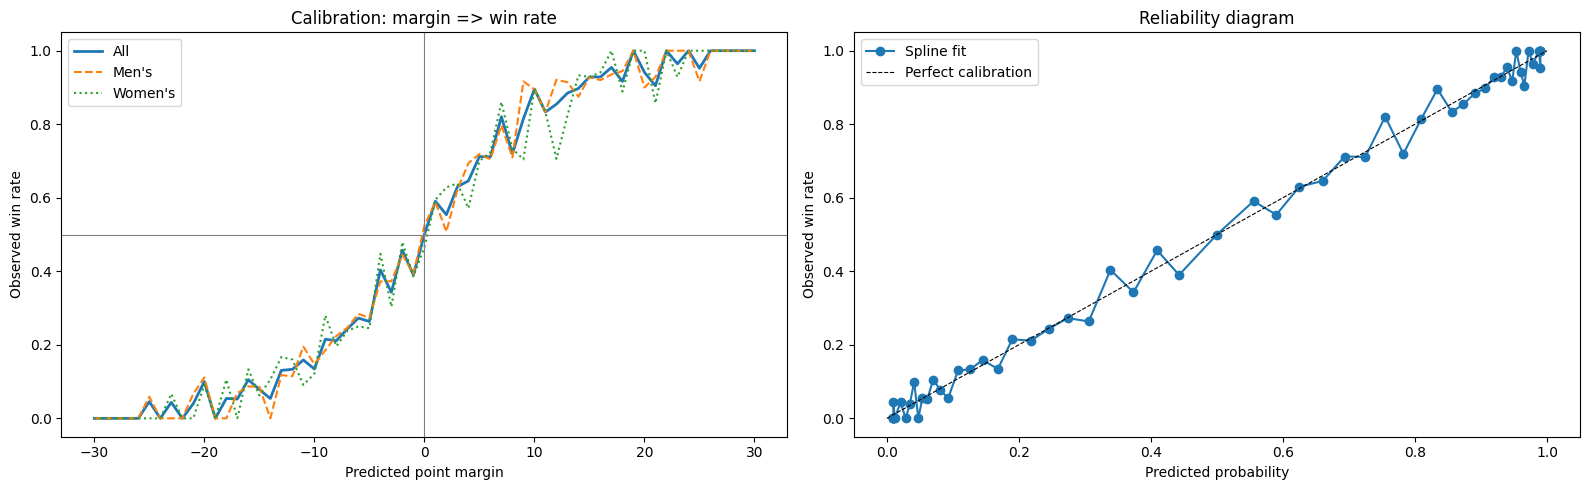

In [11]:
# Predicted margin vs observed win rate graph

oof_df = pd.DataFrame({
    "pred_margin":   oof_preds,
    "pred_prob":     oof_probs,
    "label":         oof_labels,
    "Season":        oof_seasons,
    "Divison":       df_train["Divison"].values,
})
oof_df["margin_bin"] = oof_df["pred_margin"].clip(-30, 30).astype(int)

cal_all   = oof_df.groupby("margin_bin")[["label", "pred_prob"]].mean()
cal_men   = oof_df[oof_df["Divison"] == 1].groupby("margin_bin")[["label", "pred_prob"]].mean()
cal_women = oof_df[oof_df["Divison"] == 0].groupby("margin_bin")[["label", "pred_prob"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: actual win rate vs predicted margin
axes[0].plot(cal_all.index,   cal_all["label"],   label="All",   linewidth=2)
axes[0].plot(cal_men.index,   cal_men["label"],   label="Men's", linewidth=1.5, linestyle="--")
axes[0].plot(cal_women.index, cal_women["label"], label="Women's", linewidth=1.5, linestyle=":")
axes[0].axhline(0.5, color="gray", linewidth=0.8, linestyle="-")
axes[0].axvline(0,   color="gray", linewidth=0.8, linestyle="-")
axes[0].set_xlabel("Predicted point margin")
axes[0].set_ylabel("Observed win rate")
axes[0].set_title("Calibration: margin => win rate")
axes[0].legend()

# Right: predicted probability vs observed win rate
axes[1].plot(cal_all["pred_prob"], cal_all["label"], marker="o", linewidth=1.5, label="Spline fit")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect calibration")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Observed win rate")
axes[1].set_title("Reliability diagram")
axes[1].legend()

plt.tight_layout()
plt.show()

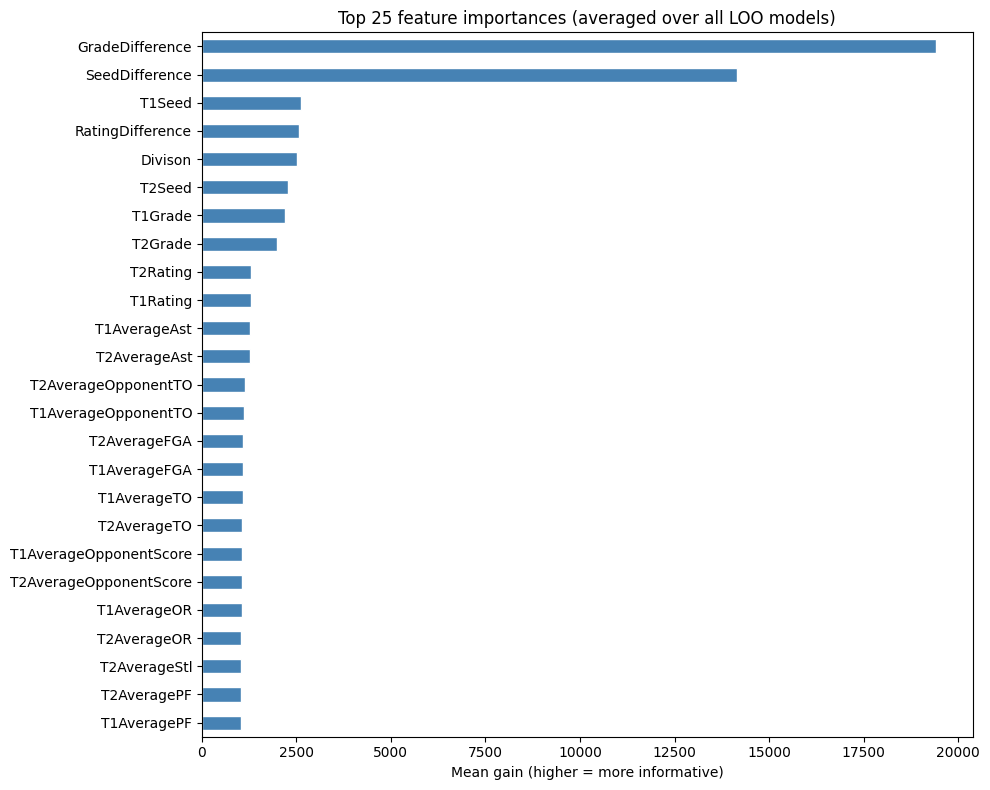

In [12]:
# Feature importance graph

importance_sum = None
for season, model in oof_models.items():
    imp = pd.Series(model.get_score(importance_type="gain"))
    importance_sum = imp if importance_sum is None else importance_sum.add(imp, fill_value=0)

importance_mean = (importance_sum / len(oof_models)).sort_values(ascending=True)
top_n = importance_mean.tail(25)

fig, ax = plt.subplots(figsize=(10, 8))
top_n.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Mean gain (higher = more informative)")
ax.set_title("Top 25 feature importances (averaged over all LOO models)")
plt.tight_layout()
plt.show()

In [13]:
# Generate submission predictions

# Align prediction features
missing_pred_cols = [f for f in FEATURES if f not in df_pred.columns]
if missing_pred_cols:
    print(f"Warning: features missing from prediction file: {missing_pred_cols}")
    print("Filling with 0. Check that predictionsMerged.csv was generated with the same feature pipeline.")
    for col in missing_pred_cols:
        df_pred[col] = 0

X_pred = df_pred[FEATURES].values
dtest  = xgb.DMatrix(X_pred, feature_names=FEATURES)

all_season_probs = []
for season, model in oof_models.items():
    margin_preds = model.predict(dtest)
    probs = np.clip(spline_model(np.clip(margin_preds, -CLIP, CLIP)), 0.01, 0.99)
    all_season_probs.append(probs)

# Simple mean ensemble
ensemble_probs = np.mean(all_season_probs, axis=0)

print(f"Prediction range: [{ensemble_probs.min():.4f}, {ensemble_probs.max():.4f}]")
print(f"Mean predicted probability: {ensemble_probs.mean():.4f}  (should be ~0.50)")

Prediction range: [0.0100, 0.9900]
Mean predicted probability: 0.5060  (should be ~0.50)


In [14]:
#  Build submission dataframe

if "ID" in df_pred.columns:
    submission = df_pred[["ID"]].copy()
else:
    # Build ID from Season + TeamID columns
    submission = pd.DataFrame()
    submission["ID"] = (
        df_pred["Season"].astype(str) + "_" +
        df_pred["T1TeamID"].astype(str) + "_" +
        df_pred["T2TeamID"].astype(str)
    )

submission["Pred"] = ensemble_probs
submission['Pred'] = submission['Pred'].apply(lambda x: x + x * 0.16 if x < 0.90 else x)
submission['Pred'] = submission['Pred'].apply(lambda x: x - x * 0.6 if x < 0.32 else x)

submission.head(10)

,ID,Pred
0,2025_1101_1102,0.540097
1,2025_1101_1103,0.120265
2,2025_1101_1104,0.016527
3,2025_1101_1105,0.628665
4,2025_1101_1106,0.427935
5,2025_1101_1107,0.553515
6,2025_1101_1108,0.628114
7,2025_1101_1110,0.481887
8,2025_1101_1111,0.493732
9,2025_1101_1112,0.012282


In [ ]:
# Save submission

SUBMISSION_FILE = "submission_xgboost.csv"
submission[["ID", "Pred"]].to_csv(SUBMISSION_FILE, index=False)
print(f"Saved {len(submission):,} rows to '{SUBMISSION_FILE}'")

try:
    from google.colab import files
    files.download(SUBMISSION_FILE)
except ImportError:
    print("Not running in Colab, file saved locally.")

Saved 131,407 rows to 'submission_xgboost.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Single-feature submission files
# Generate one submission per top feature, training XGBoost on that feature only.

TOP_FEATURES = ["GradeDifference", "SeedDifference", "T1Seed"]

for feat in TOP_FEATURES:
    print(f"\nTraining on single feature: {feat}")

    single_oof_preds   = []
    single_oof_targets = []
    single_oof_models  = {}

    for season in seasons_all:
        mask_train = df_train["Season"] != season
        mask_val   = df_train["Season"] == season

        X_tr = df_train.loc[mask_train, [feat]].values
        y_tr = df_train.loc[mask_train, "PointDifference"].values
        X_va = df_train.loc[mask_val,   [feat]].values
        y_va = df_train.loc[mask_val,   "PointDifference"].values

        dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=[feat])
        dval   = xgb.DMatrix(X_va, label=y_va, feature_names=[feat])

        model = xgb.train(
            params=PARAMS,
            dtrain=dtrain,
            num_boost_round=NUM_ROUNDS,
            verbose_eval=False,
        )

        single_oof_preds.extend(model.predict(dval))
        single_oof_targets.extend(y_va)
        single_oof_models[season] = model

    # Calibrate spline on this feature's OOF predictions
    single_preds  = np.array(single_oof_preds)
    single_labels = (np.array(single_oof_targets) > 0).astype(int)

    sorted_idx = np.argsort(np.clip(single_preds, -CLIP, CLIP))
    single_spline = UnivariateSpline(
        np.clip(single_preds, -CLIP, CLIP)[sorted_idx],
        single_labels[sorted_idx],
        k=5
    )

    single_oof_probs = np.clip(single_spline(np.clip(single_preds, -CLIP, CLIP)), 0.01, 0.99)
    brier = brier_score_loss(single_labels, single_oof_probs)
    auc   = roc_auc_score(single_labels, single_oof_probs)
    print(f"  OOF Brier: {brier:.5f}  |  AUC: {auc:.5f}")

    # Generate predictions
    X_pred_single = df_pred[[feat]].values
    dtest_single  = xgb.DMatrix(X_pred_single, feature_names=[feat])

    season_probs = []
    for season, model in single_oof_models.items():
        margin_preds = model.predict(dtest_single)
        probs = np.clip(single_spline(np.clip(margin_preds, -CLIP, CLIP)), 0.01, 0.99)
        season_probs.append(probs)

    ensemble = np.mean(season_probs, axis=0)

    # Build and save submission
    if "ID" in df_pred.columns:
        sub = df_pred[["ID"]].copy()
    else:
        sub = pd.DataFrame()
        sub["ID"] = (
            df_pred["Season"].astype(str) + "_" +
            df_pred["T1TeamID"].astype(str) + "_" +
            df_pred["T2TeamID"].astype(str)
        )

    sub["Pred"] = ensemble
    fname = f"submission_{feat}.csv"
    sub[["ID", "Pred"]].to_csv(fname, index=False)
    print(f"  Saved: {fname}  |  Pred range: [{ensemble.min():.4f}, {ensemble.max():.4f}]")

    try:
        from google.colab import files
        files.download(fname)
    except ImportError:
        pass

print("\nAll 3 single-feature submissions generated.")


Training on single feature: GradeDifference
  OOF Brier: 0.17063  |  AUC: 0.82236
  Saved: submission_GradeDifference.csv  |  Pred range: [0.0112, 0.9888]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Training on single feature: SeedDifference
  OOF Brier: 0.17858  |  AUC: 0.80202
  Saved: submission_SeedDifference.csv  |  Pred range: [0.0192, 0.9810]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Training on single feature: T1Seed
  OOF Brier: 0.20297  |  AUC: 0.74425
  Saved: submission_T1Seed.csv  |  Pred range: [0.1086, 0.8118]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All 3 single-feature submissions generated.
